<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/nootbooks/Week1Day5'Real_Bioactivity_Data_from_ChEMBL'.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install chembl_webresource_client -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.9 MB/s eta 0:00:00


In [ ]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 62.7 MB/s eta 0:00:00


In [ ]:
from chembl_webresource_client.new_client import new_client
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdFingerprintGenerator
import pandas as pd
import numpy as np

In [ ]:
target = new_client.target
activity = new_client.activity

# look up the target
thrombin = target.filter(target_chembl_id='CHEMBL244').only('target_chembl_id', 'pref_name', 'organism')
print(list(thrombin))

[{'organism': 'Homo sapiens', 'pref_name': 'Coagulation factor X', 'target_chembl_id': 'CHEMBL244'}]


In [ ]:
res = activity.filter(
    target_chembl_id='CHEMBL244',
    standard_type='Ki'   # binding constant only
).only(
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_relation'
)

df_raw = pd.DataFrame.from_records(res)
print(df_raw.shape)
df_raw.head()

(4767, 8)


,canonical_smiles,molecule_chembl_id,relation,standard_relation,standard_units,standard_value,units,value
0,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,CHEMBL369583,=,=,nM,1.3,nM,1.3
1,CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(...,CHEMBL369583,=,=,nM,1.3,nM,1.3
2,CC(=N)N1CCC(Oc2ccc3c(c2)nc(C(C)C)n3Cc2ccc3ccc(...,CHEMBL176744,=,=,nM,2.0,nM,2.0
3,CCC(C)c1nc2cc(OC3CCN(C(C)=N)CC3)ccc2n1Cc1ccc2c...,CHEMBL367476,=,=,nM,3.3,nM,3.3
4,CC1CCN(C(=O)[C@H](Cc2cccc(C(=N)N)c2)NS(=O)(=O)...,CHEMBL145741,=,=,nM,1999.86,None,5.699


In [ ]:
df = df_raw.copy()
print(f"Starting shape: {df.shape}")

df = df.dropna(subset=['canonical_smiles', 'standard_value'])
print(f"After dropping missing SMILES/Values: {df.shape}")

df = df[df['standard_units']== 'nM']
print(f"After keeping only nM units: {df.shape}")

df = df[df['standard_relation'] == '=']
print(f"After keeping only '=' relations: {df.shape}")

df['standard_value'] = df['standard_value'].astype(float)
print(f"After converting values to float: {df.shape}")

df = df.drop_duplicates(subset = 'molecule_chembl_id')
print(f"After dropping duplicate molecules: {df.shape}")

valid_smiles_flags = []
for smiles in df['canonical_smiles']:
  mol = Chem.MolFromSmiles(smiles)
  if mol is None:
    valid_smiles_flags.append(False)
  else:
    valid_smiles_flags.append(True)

df = df[valid_smiles_flags]
print(f"Shape after SMILES validation: {df.shape}")

df.head()
df.to_csv('/content/drive/MyDrive/drugproj/df_day5.csv', index=False)
print("Saved to Drive.")


Starting shape: (4767, 8)
After dropping missing SMILES/Values: (4665, 8)
After keeping only nM units: (4665, 8)
After keeping only '=' relations: (4233, 8)
After converting values to float: (4233, 8)
After dropping duplicate molecules: (3741, 8)
Shape after SMILES validation: (3741, 8)
Saved to Drive.


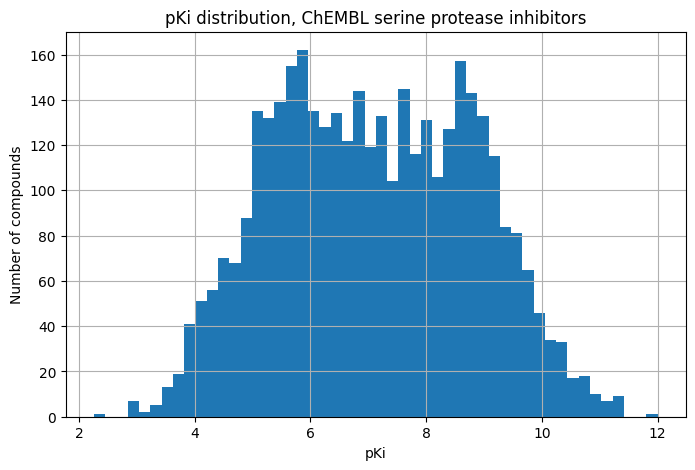

(500, 9)


In [ ]:
import matplotlib.pyplot as plt
df['pKi'] = -np.log10(df['standard_value'] * 1e-9)

# histogram
plt.figure(figsize=(8, 5))
df['pKi'].hist(bins=50)
plt.xlabel('pKi')
plt.ylabel('Number of compounds')
plt.title('pKi distribution, ChEMBL serine protease inhibitors')
plt.show()

# sample 500 for the rest of today
df_sample = df.sample(n=500, random_state=42).reset_index(drop=True)
print(df_sample.shape)

In [ ]:
def compute_properties(mol):
    """Calculates 6 core physiochemical descriptors for an RDKit Mol object."""
    return {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBD': rdMolDescriptors.CalcNumHBD(mol),
        'HBA': rdMolDescriptors.CalcNumHBA(mol),
        'TPSA': rdMolDescriptors.CalcTPSA(mol),
        'RotBonds': Descriptors.NumRotatableBonds(mol)
    }

# Create a fresh list to hold our fully evaluated rows
fully_evaluated_rows = []

# Loop through the rows of your sample using .iterrows() to stay synchronized
for index, row in df_sample.iterrows():
    smiles = row['canonical_smiles']
    chembl_id = row['molecule_chembl_id']
    standard_val = row['standard_value']

    # 1. Parse the molecule string
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        continue

    # 2. Calculate the 6 core properties
    properties_dict = compute_properties(mol)

    # 3. Calculate Lipinski violations right here manually
    violations = 0
    if properties_dict['MW'] > 500: violations += 1
    if properties_dict['LogP'] > 5: violations += 1
    if properties_dict['HBD'] > 5: violations += 1
    if properties_dict['HBA'] > 10: violations += 1

    # 4. Gather everything into one single, master dictionary
    master_row = {
        'molecule_chembl_id': chembl_id,
        'canonical_smiles': smiles,
        'standard_value': standard_val,
        'MW': properties_dict['MW'],
        'LogP': properties_dict['LogP'],
        'HBD': properties_dict['HBD'],
        'HBA': properties_dict['HBA'],
        'TPSA': properties_dict['TPSA'],
        'RotBonds': properties_dict['RotBonds'],
        'LipinskiViolations': violations
    }

    fully_evaluated_rows.append(master_row)

# Overwrite your df_sample with a fresh, perfectly aligned DataFrame
df_sample = pd.DataFrame(fully_evaluated_rows)

# Calculate and display the final statistics safely
total_rows = len(df_sample)
violators = (df_sample['LipinskiViolations'] >= 2).sum()

print(f"Compounds violating 2+ Lipinski rules: {violators}/{total_rows} ({violators/total_rows*100:.1f}%)")
df_sample.head()

Compounds violating 2+ Lipinski rules: 97/500 (19.4%)


,molecule_chembl_id,canonical_smiles,standard_value,MW,LogP,HBD,HBA,TPSA,RotBonds,LipinskiViolations
0,CHEMBL3219103,N=C(N)c1cccc(C[C@H](NS(=O)(=O)c2cccc(-c3ccc(Cl...,20.00,699.705,5.45697,5,5,157.48,10,2
1,CHEMBL421560,COc1ccc(C(=O)NCC2CCN(Cc3ccnc(O)c3)CC2)cc1OCCc1...,950.00,544.479,5.36610,2,6,83.92,10,2
2,CHEMBL39297,C/C(=C(\F)C(=O)Nc1ccc(-c2ccccc2S(N)(=O)=O)cc1C...,0.18,504.946,4.41677,4,4,139.13,6,1
3,CHEMBL209334,N=C(N)NCCC(=O)N1CCN(C(=O)[C@H](Cc2cccc(C(=N)N)...,130000.00,592.726,0.69854,6,6,198.56,11,2
4,CHEMBL410550,O=C(N[C@H]1CCC[C@H]1NS(=O)(=O)c1ccc(Cl)cc1)c1c...,11500.00,471.966,3.12030,2,4,97.27,6,0


In [ ]:
df_sample = df.sample(n=500, random_state=42).reset_index(drop=True)
df_sample.to_csv('/content/drive/MyDrive/drugproj/df_sample_day5.csv', index=False)
print("Saved to Drive.")

Saved to Drive.


Most potent: CHEMBL154238
pKi = 11.10, Ki = 0.01 nM
SMILES: CS(=O)(=O)c1ccccc1-c1ccc(NC(=O)c2cc(C(F)(F)F)nn2-c2cccc(C(=N)N)c2)cc1


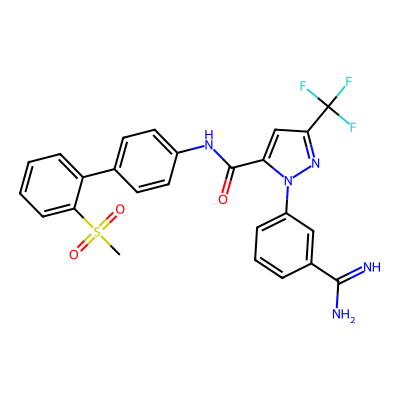

In [ ]:
# find most potent compound
most_potent_idx = df_sample['pKi'].idxmax()
most_potent = df_sample.loc[most_potent_idx]
print(f"Most potent: {most_potent['molecule_chembl_id']}")
print(f"pKi = {most_potent['pKi']:.2f}, Ki = {most_potent['standard_value']:.2f} nM")
print(f"SMILES: {most_potent['canonical_smiles']}")
Draw.MolToImage(Chem.MolFromSmiles(most_potent['canonical_smiles']), size=(400, 400))

In [ ]:
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# precompute all fingerprints once
fps = []
for smiles in df_sample['canonical_smiles']:
    mol = Chem.MolFromSmiles(smiles)
    fps.append(generator.GetFingerprint(mol))

# similarity of query to all
query_fp = fps[most_potent_idx]
similarities = [DataStructs.TanimotoSimilarity(query_fp, fp) for fp in fps]

df_sample['similarity_to_top'] = similarities

# top 10 neighbors excluding self
neighbors = df_sample[df_sample['similarity_to_top'] < 0.999].sort_values(
    'similarity_to_top', ascending=False
).head(10)

neighbors[['molecule_chembl_id', 'pKi', 'similarity_to_top']]

,molecule_chembl_id,pKi,similarity_to_top
118,CHEMBL154512,10.397940,0.666667
51,CHEMBL347931,10.221849,0.634146
26,CHEMBL559015,6.823909,0.600000
437,CHEMBL444074,8.886057,0.585714
340,CHEMBL601216,8.045757,0.564706
134,CHEMBL148944,8.744727,0.558442
232,CHEMBL151122,6.785156,0.526316
20,CHEMBL280696,8.853872,0.525641
428,CHEMBL146910,9.337242,0.524390
215,CHEMBL148718,9.267606,0.488636


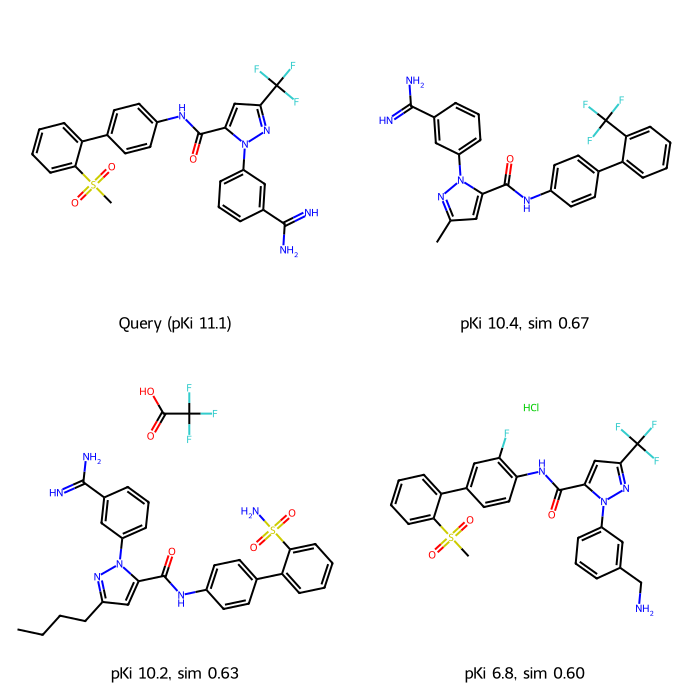

In [ ]:
top4_mols = [Chem.MolFromSmiles(most_potent['canonical_smiles'])] + \
            [Chem.MolFromSmiles(s) for s in neighbors.head(3)['canonical_smiles']]
top4_labels = [f"Query (pKi {most_potent['pKi']:.1f})"] + \
              [f"pKi {r['pKi']:.1f}, sim {r['similarity_to_top']:.2f}"
               for _, r in neighbors.head(3).iterrows()]
Draw.MolsToGridImage(top4_mols, molsPerRow=2, subImgSize=(350, 350), legends=top4_labels)

The last compound here (pKi of 6.8) is a cliff (small structural change = huge potency difference

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/drugproj', exist_ok=True)
print("Ready.")

Ready.
